In [83]:
%load_ext autoreload
%autoreload 2
import os,sys 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # hide all but GPU1
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pat
import torch 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.covariance import LedoitWolf
import json 
def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path 
root_folder = find_root_path(os.getcwd(), 'art_lang')
sys.path.append(root_folder)

import rpod.optimization.parameters as param    
import rpod.decision_transformer.manage as DT_manager
from rpod.decision_transformer.adapter import FrozenTextAdapter

device = DT_manager.device

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
#### INPUTS ####
dataset_name = 'v08'
model_name = 'v08_w3' 
ctg_condition = True  # True if you activate CTG token. False if not (= imitation learning only)
max_tokens = 50

tailored_command = True  # whether to use tailored command inputs (with waypoint info)
timestep_norm = False   # no need to touch 


In [6]:
# Get the datasets and loaders from the torch data
datasets, dataloaders = DT_manager.get_train_val_test_data(ctg_condition, dataset_name, timestep_norm, tailored_data=tailored_command)
train_loader, eval_loader, test_loader = dataloaders  
model = DT_manager.get_DT_model(model_name, train_loader, eval_loader)

# load the text encoder (and its weight)  
MODEL = os.getenv("FTA_MODEL", "distilbert-base-uncased")
text_encoder = FrozenTextAdapter(model_name=MODEL, 
                                    out_dim=model.hidden_size, 
                                    output_mode="tokens", 
                                    max_tokens=max_tokens).to(device).eval()
encoder_path = str(root_folder + "/rpod/decision_transformer/saved_files/checkpoints/" + f"{model_name}" + "/text_adapter.pth")
text_encoder.load_adapter(encoder_path)

Loading data from root/dataset/torch/...Completed, DATA IS NOT SHUFFLED YET.

GPT size: 11.1M parameters


In [59]:
# collect training data embeddings
behav = []
text = []
text_emb = torch.empty((len(train_loader.dataset), max_tokens, model.hidden_size)).to(device)

N_samples = 500
for i in range(N_samples):
    sample = train_loader.dataset.getix(i)
    behav.append(sample[10])
    text.append(sample[12])
text_emb = text_encoder(text)
# mean pooling: average over token dimension
emb = text_emb.mean(dim=1)  # (N, D)
X_train = emb.detach().cpu().numpy()   # shape (N, D)
y_train = np.array(behav)  # shape (N,)
classes = np.unique(y_train)

## Logistic Regression 

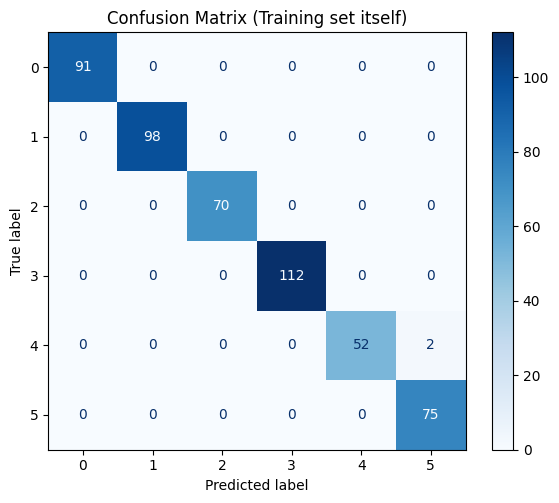

In [100]:
clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=500
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)

cm = confusion_matrix(y_train, y_pred, labels=classes)

disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Training set itself)")
plt.tight_layout()
plt.show()

In [62]:
# generate test case from test loader 
behav_eval = []
text_eval = []
text_emb_eval = torch.empty((len(eval_loader.dataset), max_tokens, model.hidden_size)).to(device)

N_eval = 2000
for i in range(N_eval):
    sample = eval_loader.dataset.getix(i)
    behav_eval.append(sample[10])
    text_eval.append(sample[12])
    
# add "none" categories for dummy
dummy = True
dummy_path = str(root_folder + "/rpod/dataset/dummy_commands.jsonl")

# open and read dummy commands
dummy_sentences = []
with open(dummy_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        dummy_sentences.append(data)
N_dummy = 200 

if dummy: 
    for i in range(N_dummy): 
        behav_eval.append("none")
        text_eval.append(dummy_sentences[i])

text_emb_eval = text_encoder(text_eval)
X_eval = text_emb_eval.mean(dim=1).detach().cpu().numpy()  # shape (N_eval + N_dummy, D)
y_eval = np.unique(behav_eval).tolist()


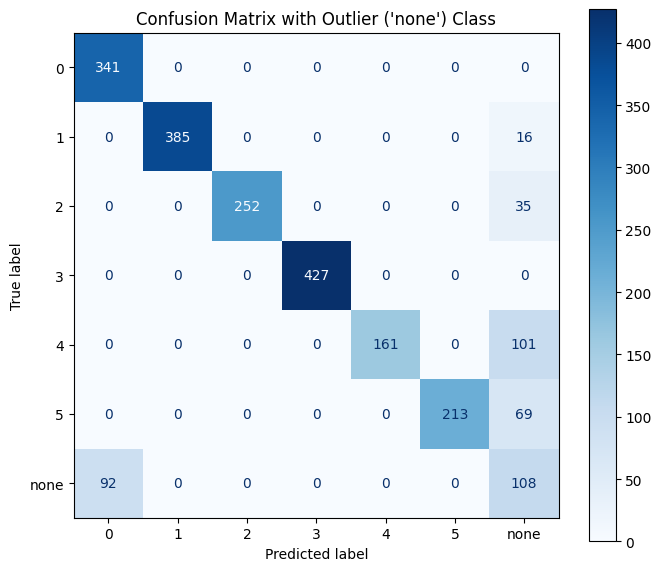

In [80]:
y_pred_prob = clf.predict_proba(X_eval)
msp = y_pred_prob.max(axis=1)
tau = 0.7
reject = msp < tau
pred_idx = y_pred_prob.argmax(axis=1)
class_names = np.array(clf.classes_)   # e.g. array(["A","B","C"])
pred = class_names[pred_idx].astype(object)
pred[reject] = "none"
true = np.array(behav_eval)

all_labels_str = [str(lbl) for lbl in y_eval]
cm = confusion_matrix(true.astype(str), pred.astype(str), labels=all_labels_str)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels_str)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix with Outlier ('none') Class")
plt.tight_layout()
plt.show()

array(['3', '0', '3', '0', '0', '2', '2', '0', '1', '3', '3', '2', '1',
       '1', '5', '3', '3', '3', '3', '4', '0', '1', '2', '1', '4', '2',
       '1', '5', '3', '1', '2', '3', '5', '0', '0', '0', '3', '1', '1',
       '4', '2', '4', '1', '0', '3', '5', '5', '0', '3', '1', '4', '3',
       '1', '3', '5', '5', '1', '2', '1', '1', '5', '5', '0', '1', '5',
       '4', '4', '3', '5', '2', '4', '2', '0', '1', '1', '5', '2', '2',
       '0', '2', '1', '2', '2', '0', '5', '2', '1', '3', '0', '5', '3',
       '3', '1', '1', '0', '3', '1', '3', '5', '0', '3', '3', '1', '5',
       '0', '3', '0', '3', '5', '1', '3', '4', '2', '5', '5', '3', '4',
       '4', '5', '0', '0', '0', '1', '4', '1', '5', '0', '3', '3', '0',
       '2', '1', '1', '3', '0', '1', '3', '0', '3', '5', '5', '2', '3',
       '0', '1', '3', '0', '3', '4', '3', '3', '3', '3', '5', '2', '0',
       '0', '4', '1', '3', '4', '0', '1', '3', '3', '3', '5', '5', '3',
       '2', '2', '2', '5', '1', '5', '0', '5', '3', '1', '3', '0

## Mahalanobis-based 

Rejection threshold tau: 352.4588


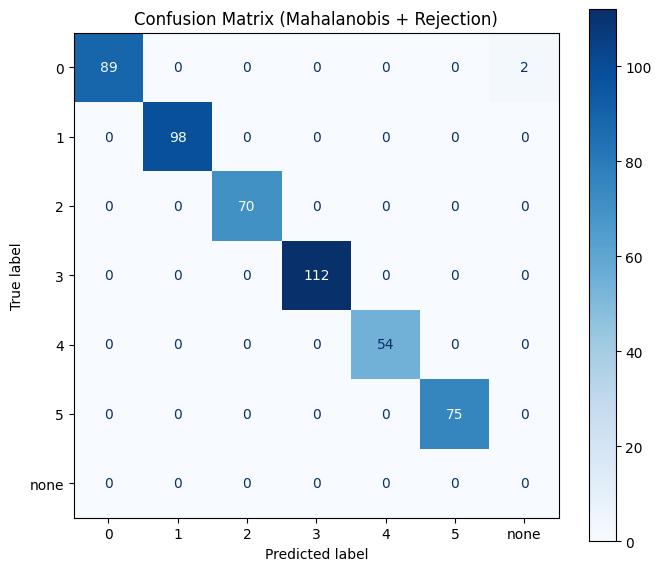

In [120]:

X = X_train
y = np.array(y_train)
classes = np.unique(y)

# Class means
means = {c: X[y == c].mean(axis=0) for c in classes}

# Shared covariance (shrinkage is important)
cov = LedoitWolf().fit(X).covariance_
inv_cov = np.linalg.inv(cov)

def mahalanobis(x, mu, inv_cov):
    d = x - mu
    return d @ inv_cov @ d

def predict_with_score(X):
    preds = []
    scores = []
    for x in X:
        # distances to each class mean
        dists = np.array([mahalanobis(x, means[c], inv_cov) for c in classes])
        j = int(np.argmin(dists))
        preds.append(classes[j])
        scores.append(dists[j])
    return np.array(preds), np.array(scores)

# Predict + score on training (or eval)
pred_train, scores_train = predict_with_score(X_train)

# Calibrate τ (e.g., reject top 1% most distant ID samples)
tau = np.quantile(scores_train, 0.997)
print(f"Rejection threshold tau: {tau:.4f}")

reject = scores_train > tau

# Build final predictions with "none"
pred_final = pred_train.astype(object)
pred_final[reject] = "none"

# ---- FIX: convert labels to strings for confusion matrix ----
y_str = y.astype(str)
pred_str = pred_final.astype(str)
labels_with_none = list(classes.astype(str)) + ["none"]

cm = confusion_matrix(y_str, pred_str, labels=labels_with_none)

disp = ConfusionMatrixDisplay(cm, display_labels=labels_with_none)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Mahalanobis + Rejection)")
plt.tight_layout()
plt.show()

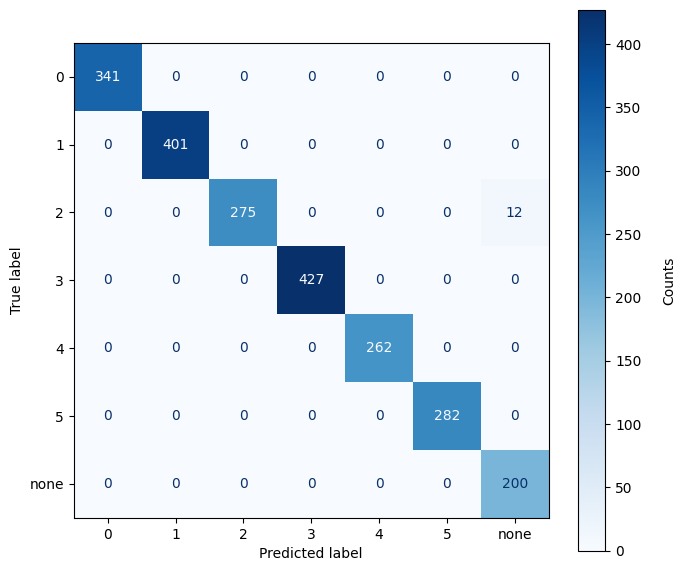

tau = 1500.0000 | reject rate (eval) = 9.636%


In [124]:

pred_eval, scores_eval = predict_with_score(X_eval)

tau = 1500
reject = scores_eval > tau

# --- assign "none" to rejected ---
pred = pred_eval.astype(object)
pred[reject] = "none"

true = np.array(behav_eval)

# --- confusion matrix (string-safe) ---
labels = list(map(str, classes)) + ["none"]   # include outlier label
cm = confusion_matrix(true.astype(str), pred.astype(str), labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format="d")
cbar = fig.axes[-1]        # colorbar axis
cbar.set_ylabel("Counts", rotation=90, labelpad=15)

plt.tight_layout()
plt.show()

print(f"tau = {tau:.4f} | reject rate (eval) = {reject.mean():.3%}")

In [126]:
# save 
fig.savefig("confusion_matrix_eval_mahalanobis_outlier.png", dpi=600)